# Parte 2 — Tokenización y vocabularios
Entrada: `data/spa_normalized.tsv` (texto normalizado en el EDA, **sin** filtro de longitud).
Salida: tokenizador, filtro de longitud definitivo, splits train/val/test y vocabularios.

## 10. Elección del tokenizador
Decisión abierta del EDA: ¿`don't` / `Tom's` como una palabra (A) o separados en `don` + `'t` / `Tom` + `'s` (B)?

In [1]:
import os, re, csv, random, collections
import numpy as np
import pandas as pd
from google.colab import drive

drive.mount("/content/drive")
PROJ = "/content/drive/MyDrive/Proyecto_traductor"
DATA = os.path.join(PROJ, "data")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
pd.set_option("display.max_colwidth", 120); pd.set_option("display.width", 200)

base = pd.read_csv(os.path.join(DATA, "spa_normalized.tsv"), sep="\t", header=None,
                   names=["english", "spanish", "attribution"],
                   quoting=csv.QUOTE_NONE, dtype=str, keep_default_na=False, encoding="utf-8")
print("Filas cargadas:", f"{len(base):,}", "(esperado: 144,215)")
display(base[["english", "spanish"]].sample(5, random_state=SEED))

Mounted at /content/drive
Filas cargadas: 144,215 (esperado: 144,215)


,english,spanish
31486,It's too far to walk.,Es demasiado lejos para ir andando.
93534,Come over here and give me a kiss.,Ven para acá y dame un beso.
74169,Tom's remark was insensitive.,La observación de Tom fue insensible.
106812,There's someone I'd like you to meet.,Hay alguien que me gustaría que conocierais.
71409,I have just finished my work.,Recién acabo de terminar mi trabajo.


In [2]:
# A: palabra (con apóstrofes internos pegados) | signo de puntuación suelto
TOK_A = re.compile(r"\w+(?:'\w+)*|[^\w\s]")
# B: palabra | sufijo de contracción inglesa separado ('s 't 'm 're 'll 've 'd) | signo suelto
TOK_B = re.compile(r"\w+|'(?:s|t|m|re|ll|ve|d)\b|[^\w\s]")

print("=== Ejemplos de tokenización ===")
tests = ["I don't know Tom's sister.", "How are you?", "¿Cómo estás, Tom?",
         '"Is he lying?" "Obviously."', "It's 2:30, o'clock.", "Trabajo para McDonald's."]
tests += list(base["english"].sample(3, random_state=SEED))
for s in tests:
    print(f"\n{s!r}\n  A: {TOK_A.findall(s)}\n  B: {TOK_B.findall(s)}")

def analyze(tok_re):
    en_t = base["english"].map(tok_re.findall)
    es_t = base["spanish"].map(tok_re.findall)
    out = {}
    for lang, toks in [("EN", en_t), ("ES", es_t)]:
        cnt = collections.Counter(t for ts in toks for t in ts)
        total = sum(cnt.values())
        out[f"{lang} tokens totales"] = total
        out[f"{lang} tipos distintos"] = len(cnt)
        out[f"{lang} tipos con freq=1"] = sum(1 for c in cnt.values() if c == 1)
        for mf in [2, 3, 5]:
            out[f"{lang} tipos con freq>={mf}"] = sum(1 for c in cnt.values() if c >= mf)
            out[f"{lang} % tokens que serían <UNK> (min_freq={mf})"] = sum(c for c in cnt.values() if c < mf) / total * 100
        lens = toks.map(len)
        out[f"{lang} media tokens/oración"] = lens.mean()
        out[f"{lang} P99 tokens"] = lens.quantile(0.99)
    both = np.maximum(en_t.map(len), es_t.map(len))
    for L in [25, 27, 30]:
        out[f"Pares con ambos lados <= {L} tokens (%)"] = (both <= L).mean() * 100
    return out

cmp_tok = pd.DataFrame({"A: contracciones pegadas": analyze(TOK_A),
                        "B: sufijos separados": analyze(TOK_B)})
print("\n=== Comparación A vs B (sobre todo el dataset; solo para decidir el diseño) ===")
display(cmp_tok.round(3))

=== Ejemplos de tokenización ===

"I don't know Tom's sister."
  A: ['I', "don't", 'know', "Tom's", 'sister', '.']
  B: ['I', 'don', "'t", 'know', 'Tom', "'s", 'sister', '.']

'How are you?'
  A: ['How', 'are', 'you', '?']
  B: ['How', 'are', 'you', '?']

'¿Cómo estás, Tom?'
  A: ['¿', 'Cómo', 'estás', ',', 'Tom', '?']
  B: ['¿', 'Cómo', 'estás', ',', 'Tom', '?']

'"Is he lying?" "Obviously."'
  A: ['"', 'Is', 'he', 'lying', '?', '"', '"', 'Obviously', '.', '"']
  B: ['"', 'Is', 'he', 'lying', '?', '"', '"', 'Obviously', '.', '"']

"It's 2:30, o'clock."
  A: ["It's", '2', ':', '30', ',', "o'clock", '.']
  B: ['It', "'s", '2', ':', '30', ',', 'o', "'", 'clock', '.']

"Trabajo para McDonald's."
  A: ['Trabajo', 'para', "McDonald's", '.']
  B: ['Trabajo', 'para', 'McDonald', "'s", '.']

"It's too far to walk."
  A: ["It's", 'too', 'far', 'to', 'walk', '.']
  B: ['It', "'s", 'too', 'far', 'to', 'walk', '.']

'Come over here and give me a kiss.'
  A: ['Come', 'over', 'here', 'and', 'give', 

,A: contracciones pegadas,B: sufijos separados
EN tokens totales,1052679.000,1099213.000
EN tipos distintos,16352.000,15935.000
EN tipos con freq=1,5603.000,5414.000
EN tipos con freq>=2,10749.000,10521.000
EN % tokens que serían <UNK> (min_freq=2),0.532,0.493
EN tipos con freq>=3,8459.000,8282.000
EN % tokens que serían <UNK> (min_freq=3),0.967,0.900
EN tipos con freq>=5,6326.000,6194.000
EN % tokens que serían <UNK> (min_freq=5),1.656,1.545
EN media tokens/oración,7.299,7.622


## 11. Tokenizador final, filtro de longitud y diagnóstico de grupos
Decisión de la sección 10: **tokenizador A** (`don't`, `Tom's` pegados; puntuación como token).
Filtro de longitud: `MAX_TOKENS = 25` de contenido (27 con `<SOS>`/`<EOS>`).
Antes del split, comprobamos cómo quedan los grupos para evitar leakage.

In [3]:
# =========================
# 11. TOKENIZADOR FINAL + FILTRO + DIAGNÓSTICO DE GRUPOS
# =========================
TOKEN_RE = TOK_A                       # decisión de la sección 10
def tokenize(text):
    return TOKEN_RE.findall(text)

MAX_TOKENS = 25                        # tokens de contenido (sin <SOS>/<EOS>)

data = base.copy()
data["en_tokens"] = data["english"].map(tokenize)
data["es_tokens"] = data["spanish"].map(tokenize)
max_len = np.maximum(data["en_tokens"].map(len), data["es_tokens"].map(len))
keep = max_len <= MAX_TOKENS
print(f"Pares antes del filtro : {len(data):,}")
print(f"Eliminados (> {MAX_TOKENS} tokens): {(~keep).sum():,}  (el EDA anticipó 109)")
data = data[keep].reset_index(drop=True)
print(f"Pares después          : {len(data):,}  (el EDA anticipó 144,106)")

# --- Grupos: componentes conexas del grafo inglés <-> español (claves normalizadas) ---
def norm_key(s):
    return re.sub(r"[^\w\s]", "", s.lower()).strip()

key_en = data["english"].map(norm_key)
key_es = data["spanish"].map(norm_key)

parent = {}
def find(x):
    while parent.setdefault(x, x) != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

for e, s in zip(key_en, key_es):
    union(("en", e), ("es", s))

gid = {}
data["group"] = [gid.setdefault(find(("en", e)), len(gid)) for e in key_en]

sizes = data.groupby("group").size()
print("\n=== Diagnóstico de grupos ===")
print(f"Frases inglesas exactas distintas            : {data['english'].nunique():,}")
print(f"Claves inglesas normalizadas distintas       : {key_en.nunique():,}")
print(f"Grupos (componentes conexas EN<->ES)         : {len(sizes):,}")
print(f"Tamaño de grupo -> mediana: {sizes.median():.0f} | media: {sizes.mean():.2f} | "
      f"P99: {sizes.quantile(0.99):.0f} | máx: {sizes.max():,}")
print(f"Grupos de 1 fila: {(sizes == 1).sum():,} ({(sizes == 1).mean()*100:.1f}% de los grupos)")
print("\nLos 8 grupos más grandes (nº de filas):", sizes.sort_values(ascending=False).head(8).tolist())
print(f"Filas en el grupo más grande: {sizes.max():,} ({sizes.max()/len(data)*100:.3f}% del dataset)")

print("\nEjemplos del grupo más grande:")
top = sizes.idxmax()
display(data[data["group"] == top][["english", "spanish"]].sample(min(10, sizes.max()), random_state=SEED))

Pares antes del filtro : 144,215
Eliminados (> 25 tokens): 109  (el EDA anticipó 109)
Pares después          : 144,106  (el EDA anticipó 144,106)

=== Diagnóstico de grupos ===
Frases inglesas exactas distintas            : 121,385
Claves inglesas normalizadas distintas       : 121,222
Grupos (componentes conexas EN<->ES)         : 112,998
Tamaño de grupo -> mediana: 1 | media: 1.28 | P99: 5 | máx: 68
Grupos de 1 fila: 93,843 (83.0% de los grupos)

Los 8 grupos más grandes (nº de filas): [68, 58, 43, 43, 42, 39, 39, 36]
Filas en el grupo más grande: 68 (0.047% del dataset)

Ejemplos del grupo más grande:


,english,spanish
33850,You can put it there.,Podéis ponerla ahí.
33820,You can put it there.,Lo puedes dejar ahí.
33808,You can put it there.,Lo podéis poner ahí.
33813,You can put it there.,Lo puede poner allí.
33832,You can put it there.,Lo pueden dejar ahí.
33845,You can put it there.,Puedes ponerla allí.
33862,You can put it there.,Vosotras la podéis poner ahí.
33809,You can put it there.,Lo podéis poner allí.
33865,You can put it there.,Ustedes lo pueden poner ahí.
33816,You can put it there.,Lo pueden poner ahí.


## 12. Split train / validation / test (por grupos, sin leakage)
Proporción 90/5/5 medida en **filas**, asignando **grupos completos** a cada conjunto.
Verificaciones: ningún grupo, inglés ni español aparece en más de un conjunto, y los conjuntos tienen distribuciones parecidas.

In [4]:
# =========================
# 12. SPLIT POR GRUPOS
# =========================
import json
TRAIN_FRAC, VAL_FRAC = 0.90, 0.05          # test = el resto
rng = np.random.default_rng(SEED)

perm = rng.permutation(sizes.index.to_numpy())               # orden aleatorio de grupos
cum = np.cumsum(sizes.loc[perm].to_numpy()) / len(data)      # fracción acumulada de FILAS
split_of_group = np.where(cum <= TRAIN_FRAC, "train",
                  np.where(cum <= TRAIN_FRAC + VAL_FRAC, "val", "test"))
data["split"] = data["group"].map(dict(zip(perm, split_of_group)))
data["key_en"], data["key_es"] = key_en, key_es
data["en_len"] = data["en_tokens"].map(len)
data["es_len"] = data["es_tokens"].map(len)

# --- Tamaños ---
print("=== Tamaños ===")
summary = data.groupby("split").agg(
    filas=("english", "size"),
    grupos=("group", "nunique"),
    ingles_unicos=("english", "nunique"),
    media_en_toks=("en_len", "mean"),
    media_es_toks=("es_len", "mean"),
    p95_en=("en_len", lambda s: s.quantile(0.95)),
    p95_es=("es_len", lambda s: s.quantile(0.95)),
).loc[["train", "val", "test"]]
summary["% filas"] = summary["filas"] / len(data) * 100
display(summary.round(3))

# --- Verificaciones anti-leakage ---
print("\n=== Verificaciones anti-leakage (todo debe ser 0) ===")
print("Grupos presentes en más de un split:", int((data.groupby("group")["split"].nunique() > 1).sum()))
for col, name in [("english", "inglés exacto"), ("spanish", "español exacto"),
                  ("key_en", "inglés normalizado"), ("key_es", "español normalizado")]:
    sets = {sp: set(data.loc[data["split"] == sp, col]) for sp in ["train", "val", "test"]}
    print(f"{name:20s} train∩val={len(sets['train'] & sets['val'])} | "
          f"train∩test={len(sets['train'] & sets['test'])} | val∩test={len(sets['val'] & sets['test'])}")

# --- ¿Los splits son comparables? (traducciones múltiples por grupo) ---
gsize = data["group"].map(sizes)
print("\n=== % de filas que pertenecen a grupos con 2+ filas, por split ===")
print((data.assign(multi=gsize >= 2).groupby("split")["multi"].mean().loc[["train", "val", "test"]] * 100).round(2).to_string())

# --- Guardar splits en Drive ---
SPLIT_DIR = os.path.join(DATA, "splits")
os.makedirs(SPLIT_DIR, exist_ok=True)
for sp in ["train", "val", "test"]:
    d = data[data["split"] == sp]
    with open(os.path.join(SPLIT_DIR, f"{sp}.tsv"), "w", encoding="utf-8", newline="\n") as f:
        for e, s, a, g in zip(d["english"], d["spanish"], d["attribution"], d["group"]):
            f.write(f"{e}\t{s}\t{a}\t{g}\n")
with open(os.path.join(SPLIT_DIR, "split_log.json"), "w", encoding="utf-8") as f:
    json.dump({"seed": SEED, "fracs": {"train": TRAIN_FRAC, "val": VAL_FRAC, "test": round(1 - TRAIN_FRAC - VAL_FRAC, 4)},
               "max_tokens": MAX_TOKENS, "filas": {sp: int((data["split"] == sp).sum()) for sp in ["train", "val", "test"]},
               "grupos_total": int(len(sizes))}, f, indent=2)
print("\nGuardado en:", SPLIT_DIR, "->", os.listdir(SPLIT_DIR))

=== Tamaños ===


,filas,grupos,ingles_unicos,media_en_toks,media_es_toks,p95_en,p95_es,% filas
split,,,,,,,,
train,129695,101809,109360,7.292,7.191,12.0,12.0,90.0
val,7205,5500,5950,7.180,7.085,12.0,12.0,5.0
test,7206,5689,6075,7.233,7.159,12.0,12.0,5.0



=== Verificaciones anti-leakage (todo debe ser 0) ===
Grupos presentes en más de un split: 0
inglés exacto        train∩val=0 | train∩test=0 | val∩test=0
español exacto       train∩val=0 | train∩test=0 | val∩test=0
inglés normalizado   train∩val=0 | train∩test=0 | val∩test=0
español normalizado  train∩val=0 | train∩test=0 | val∩test=0

=== % de filas que pertenecen a grupos con 2+ filas, por split ===
split
train    34.82
val      36.95
test     33.87

Guardado en: /content/drive/MyDrive/Proyecto_traductor/data/splits -> ['train.tsv', 'val.tsv', 'test.tsv', 'split_log.json']


## 13. Vocabularios (construidos solo con train)
Tokens especiales: `<PAD>=0`, `<UNK>=1`, `<SOS>=2`, `<EOS>=3`.
`min_freq` se elige con la tasa de `<UNK>` en **validación** (nunca en test).

In [5]:
# =========================
# 13. VOCABULARIOS (solo train) + DIAGNÓSTICO DE <UNK> EN VALIDACIÓN
# =========================
PAD, UNK, SOS, EOS = "<PAD>", "<UNK>", "<SOS>", "<EOS>"
SPECIALS = [PAD, UNK, SOS, EOS]           # índices 0, 1, 2, 3

train = data[data["split"] == "train"]
val   = data[data["split"] == "val"]

def count_tokens(token_lists):
    c = collections.Counter()
    for ts in token_lists:
        c.update(ts)
    return c

cnt_en, cnt_es = count_tokens(train["en_tokens"]), count_tokens(train["es_tokens"])

def build_vocab(counter, min_freq):
    words = [w for w, c in sorted(counter.items(), key=lambda kv: (-kv[1], kv[0])) if c >= min_freq]
    itos = SPECIALS + words                # index -> palabra
    stoi = {w: i for i, w in enumerate(itos)}   # palabra -> index
    return stoi, itos

def unk_stats(token_lists, stoi):
    total = unk = sents_with_unk = 0
    for ts in token_lists:
        u = sum(1 for t in ts if t not in stoi)
        total += len(ts); unk += u; sents_with_unk += (u > 0)
    return unk / total * 100, sents_with_unk / len(token_lists) * 100

# --- 13.1 ¿Qué min_freq conviene? (medido en VALIDACIÓN) ---
rows = []
for mf in [1, 2, 3, 5]:
    stoi_en, _ = build_vocab(cnt_en, mf)
    stoi_es, _ = build_vocab(cnt_es, mf)
    en_tok, en_sent = unk_stats(val["en_tokens"], stoi_en)
    es_tok, es_sent = unk_stats(val["es_tokens"], stoi_es)
    rows.append({"min_freq": mf, "vocab EN": len(stoi_en), "vocab ES": len(stoi_es),
                 "val EN %tokens UNK": en_tok, "val EN %oraciones c/UNK": en_sent,
                 "val ES %tokens UNK": es_tok, "val ES %oraciones c/UNK": es_sent})
print("=== 13.1 min_freq vs tasa de <UNK> en validación ===")
display(pd.DataFrame(rows).round(3))

# --- 13.2 Vocabulario con el min_freq candidato ---
MIN_FREQ = 1
stoi_en, itos_en = build_vocab(cnt_en, MIN_FREQ)
stoi_es, itos_es = build_vocab(cnt_es, MIN_FREQ)
print(f"\n=== 13.2 Vocabularios con min_freq={MIN_FREQ} ===")
print(f"EN: {len(itos_en):,} entradas | ES: {len(itos_es):,} entradas")
print("Primeras entradas EN:", itos_en[:14])
print("Primeras entradas ES:", itos_es[:14])
for sp in [PAD, UNK, SOS, EOS]:
    assert stoi_en[sp] == stoi_es[sp] == SPECIALS.index(sp)

# --- 13.3 ¿Qué palabras son <UNK> en validación? ---
def unk_words(token_lists, stoi):
    return collections.Counter(t for ts in token_lists for t in ts if t not in stoi)

def categorize(t):
    if any(ch.isdigit() for ch in t): return "contiene dígitos"
    if t[0].isupper(): return "capitalizada (nombre propio / inicio)"
    return "minúscula (palabra rara)"

for lang, col, stoi in [("EN", "en_tokens", stoi_en), ("ES", "es_tokens", stoi_es)]:
    uw = unk_words(val[col], stoi)
    total = sum(uw.values())
    cats = collections.Counter()
    for w, c in uw.items():
        cats[categorize(w)] += c
    print(f"\n[{lang}] {total:,} tokens <UNK> en validación ({len(uw):,} palabras distintas)")
    print("  por categoría:", {k: f"{v/total*100:.1f}%" for k, v in cats.most_common()})
    print("  top 25:", uw.most_common(25))

# --- 13.4 Ejemplos con <UNK> ---
print("\n=== 13.4 Ejemplos de validación con <UNK> ===")
mask = val["en_tokens"].map(lambda ts: any(t not in stoi_en for t in ts))
for _, r in val[mask].sample(6, random_state=SEED).iterrows():
    print("EN:", " ".join(t if t in stoi_en else "<UNK>" for t in r["en_tokens"]))
    print("ES:", " ".join(t if t in stoi_es else "<UNK>" for t in r["es_tokens"]), "\n")

=== 13.1 min_freq vs tasa de <UNK> en validación ===


,min_freq,vocab EN,vocab ES,val EN %tokens UNK,val EN %oraciones c/UNK,val ES %tokens UNK,val ES %oraciones c/UNK
0,1,15654,30263,0.686,4.552,1.554,10.257
1,2,10231,17512,1.125,7.231,2.468,15.975
2,3,8037,12852,1.521,9.521,3.213,20.194
3,5,6009,8795,2.138,12.908,4.469,27.217



=== 13.2 Vocabularios con min_freq=1 ===
EN: 15,654 entradas | ES: 30,263 entradas
Primeras entradas EN: ['<PAD>', '<UNK>', '<SOS>', '<EOS>', '.', 'I', 'to', 'the', 'Tom', 'you', 'a', '?', 'is', 'in']
Primeras entradas ES: ['<PAD>', '<UNK>', '<SOS>', '<EOS>', '.', 'de', 'que', 'Tom', 'a', '?', '¿', 'la', 'en', 'el']

[EN] 355 tokens <UNK> en validación (311 palabras distintas)
  por categoría: {'minúscula (palabra rara)': '74.6%', 'capitalizada (nombre propio / inicio)': '24.5%', 'contiene dígitos': '0.8%'}
  top 25: [('robots', 4), ('Fantastic', 3), ('brightened', 3), ('pusher', 3), ('repeats', 3), ('unclear', 3), ('Terrific', 2), ('doomed', 2), ('booked', 2), ('squabbling', 2), ('geek', 2), ('Checks', 2), ('resilient', 2), ('partied', 2), ('Elves', 2), ('pointy', 2), ('seeks', 2), ('kilo', 2), ('dime', 2), ('Appearances', 2), ('deceiving', 2), ('Brevity', 2), ('Suicide', 2), ('Bigger', 2), ('companions', 2)]

[ES] 793 tokens <UNK> en validación (716 palabras distintas)
  por categor

In [6]:
# ============================================
# EXPORTACIÓN DE VOCABULARIOS Y CONFIGURACIÓN
# ============================================

import json

VOCAB_DIR = os.path.join(PROJ, "vocabularios")
os.makedirs(VOCAB_DIR, exist_ok=True)

# 1. Guardar mapeos palabra -> índice (stoi)
with open(os.path.join(VOCAB_DIR, "vocab_english.json"), "w", encoding="utf-8") as f:
    json.dump(stoi_en, f, ensure_ascii=False, indent=2)

with open(os.path.join(VOCAB_DIR, "vocab_spanish.json"), "w", encoding="utf-8") as f:
    json.dump(stoi_es, f, ensure_ascii=False, indent=2)

# 2. Guardar listas índice -> palabra (itos)
with open(os.path.join(VOCAB_DIR, "itos_english.json"), "w", encoding="utf-8") as f:
    json.dump(itos_en, f, ensure_ascii=False, indent=2)

with open(os.path.join(VOCAB_DIR, "itos_spanish.json"), "w", encoding="utf-8") as f:
    json.dump(itos_es, f, ensure_ascii=False, indent=2)

# 3. Guardar metadatos y configuración clave de la tokenización
vocab_config = {
    "MAX_TOKENS": MAX_TOKENS,
    "MAX_SEQ_LEN": MAX_TOKENS + 2, # Contenido + <SOS> + <EOS>
    "MIN_FREQ": MIN_FREQ,
    "VOCAB_SIZE_EN": len(itos_en),
    "VOCAB_SIZE_ES": len(itos_es),
    "SPECIAL_TOKENS": {
        "<PAD>": 0,
        "<UNK>": 1,
        "<SOS>": 2,
        "<EOS>": 3
    }
}

with open(os.path.join(VOCAB_DIR, "vocab_config.json"), "w", encoding="utf-8") as f:
    json.dump(vocab_config, f, ensure_ascii=False, indent=2)

print("=" * 60)
print("¡ARTEFACTOS DE TOKENIZACIÓN Y VOCABULARIO GUARDADOS EXITOSAMENTE!")
print("=" * 60)
print(f"Directorio: {VOCAB_DIR}")
print("Archivos generados:")
print("  ├── vocab_english.json")
print("  ├── vocab_spanish.json")
print("  ├── itos_english.json")
print("  ├── itos_spanish.json")
print("  └── vocab_config.json")

¡ARTEFACTOS DE TOKENIZACIÓN Y VOCABULARIO GUARDADOS EXITOSAMENTE!
Directorio: /content/drive/MyDrive/Proyecto_traductor/vocabularios
Archivos generados:
  ├── vocab_english.json
  ├── vocab_spanish.json
  ├── itos_english.json
  ├── itos_spanish.json
  └── vocab_config.json


In [7]:
# ============================================
# 1. SETUP, CARGA DE VOCABULARIOS Y DATASET
# ============================================

import os
import re
import json
import math
import time
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from google.colab import drive

# 1. Montar Google Drive
drive.mount("/content/drive")
PROJ = "/content/drive/MyDrive/Proyecto_traductor"
DATA_DIR = os.path.join(PROJ, "data")
SPLIT_DIR = os.path.join(DATA_DIR, "splits")
VOCAB_DIR = os.path.join(PROJ, "vocabularios")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo activo: {DEVICE}")

# 2. Cargar Vocabularios previamente exportados
with open(os.path.join(VOCAB_DIR, "vocab_english.json"), "r", encoding="utf-8") as f:
    stoi_en = json.load(f)

with open(os.path.join(VOCAB_DIR, "vocab_spanish.json"), "r", encoding="utf-8") as f:
    stoi_es = json.load(f)

with open(os.path.join(VOCAB_DIR, "vocab_config.json"), "r", encoding="utf-8") as f:
    vocab_cfg = json.load(f)

MAX_TOKENS = vocab_cfg["MAX_TOKENS"]
MAX_SEQ_LEN = vocab_cfg["MAX_SEQ_LEN"]

PAD_IDX = vocab_cfg["SPECIAL_TOKENS"]["<PAD>"]  # 0
UNK_IDX = vocab_cfg["SPECIAL_TOKENS"]["<UNK>"]  # 1
SOS_IDX = vocab_cfg["SPECIAL_TOKENS"]["<SOS>"]  # 2
EOS_IDX = vocab_cfg["SPECIAL_TOKENS"]["<EOS>"]  # 3

# 3. Tokenizador por Reglas (Opción A: contracciones pegadas)
TOK_RE = re.compile(r"\w+(?:'\w+)*|[^\w\s]")
def tokenize(text):
    return TOK_RE.findall(str(text))

# 4. Clase Custom Dataset para PyTorch
class TranslationDataset(Dataset):
    def __init__(self, tsv_file, stoi_src, stoi_tgt, max_len=MAX_TOKENS):
        self.pairs = []
        self.stoi_src = stoi_src
        self.stoi_tgt = stoi_tgt
        self.max_len = max_len

        with open(tsv_file, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.rstrip("\n").split("\t")
                if len(parts) >= 2:
                    self.pairs.append((parts[0], parts[1]))

    def __len__(self):
        return len(self.pairs)

    def encode(self, text, stoi):
        tokens = tokenize(text)[:self.max_len]
        ids = [stoi.get(t, UNK_IDX) for t in tokens]
        ids = [SOS_IDX] + ids + [EOS_IDX]
        padding = [PAD_IDX] * (self.max_len + 2 - len(ids))
        return ids + padding

    def __getitem__(self, idx):
        src_text, tgt_text = self.pairs[idx]
        src_ids = self.encode(src_text, self.stoi_src)
        tgt_ids = self.encode(tgt_text, self.stoi_tgt)
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)

# Instanciar Datasets y DataLoaders
BATCH_SIZE = 64

train_dataset = TranslationDataset(os.path.join(SPLIT_DIR, "train.tsv"), stoi_en, stoi_es)
val_dataset   = TranslationDataset(os.path.join(SPLIT_DIR, "val.tsv"), stoi_en, stoi_es)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample_src, sample_tgt = next(iter(train_loader))
print(f"\nDimensiones verfagadas:")
print(f"  Batch Train Src (Inglés) : {sample_src.shape}") # [64, 27]
print(f"  Batch Train Tgt (Español): {sample_tgt.shape}") # [64, 27]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dispositivo activo: cuda

Dimensiones verfagadas:
  Batch Train Src (Inglés) : torch.Size([64, 27])
  Batch Train Tgt (Español): torch.Size([64, 27])


In [8]:
# ============================================
# 2. ARQUITECTURA TRANSFORMER: COMPONENTES BÁSICOS
# ============================================

import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model debe ser divisible entre n_heads"
        self.d_k = d_model // n_heads
        self.n_heads = n_heads

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        B = q.size(0)

        # Proyecciones lineales y reshape a (B, n_heads, seq_len, d_k)
        Q = self.w_q(q).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.w_k(k).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.w_v(v).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)

        # Scaled Dot-Product Attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.n_heads * self.d_k)
        return self.w_o(out)


class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

In [9]:
# ============================================
# 3. ENCODER, DECODER Y MODELO TRANSFORMER
# ============================================

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, mask)))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x


class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout=0.1, max_len=100):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model

    def forward(self, src, mask):
        x = self.embed(src) * math.sqrt(self.d_model)
        x = self.dropout(self.pos_enc(x))
        for layer in self.layers:
            x = layer(x, mask)
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask, tgt_mask):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, tgt_mask)))
        x = self.norm2(x + self.dropout(self.cross_attn(x, enc_out, enc_out, src_mask)))
        x = self.norm3(x + self.dropout(self.ff(x)))
        return x


class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout=0.1, max_len=100):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model

    def forward(self, tgt, enc_out, src_mask, tgt_mask):
        x = self.embed(tgt) * math.sqrt(self.d_model)
        x = self.dropout(self.pos_enc(x))
        for layer in self.layers:
            x = layer(x, enc_out, src_mask, tgt_mask)
        return self.fc_out(x)


class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, n_heads=8, d_ff=512,
                 n_layers=3, dropout=0.1, max_len=100, pad_idx=PAD_IDX):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len)
        self.decoder = Decoder(tgt_vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len)
        self.pad_idx = pad_idx

    def make_src_mask(self, src):
        return (src != self.pad_idx).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):
        pad_mask = (tgt != self.pad_idx).unsqueeze(1).unsqueeze(2)
        L = tgt.size(1)
        sub_mask = torch.tril(torch.ones((L, L), device=tgt.device)).bool()
        return pad_mask & sub_mask

    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        enc_out = self.encoder(src, src_mask)
        return self.decoder(tgt, enc_out, src_mask, tgt_mask)

Parámetros entrenables del Transformer: 25,061,943

INICIANDO ENTRENAMIENTO DEL TRANSFORMER (MEJORADO)
Época 01/10 | Train Loss: 5.1006 | Val Loss: 3.7659 | LR: 0.000993 | Tiempo: 135.7s   [BEST MODEL GUARDADO]
Época 02/10 | Train Loss: 3.6391 | Val Loss: 3.2880 | LR: 0.000702 | Tiempo: 135.2s   [BEST MODEL GUARDADO]
Época 03/10 | Train Loss: 3.3000 | Val Loss: 3.1336 | LR: 0.000573 | Tiempo: 135.2s   [BEST MODEL GUARDADO]
Época 04/10 | Train Loss: 3.1419 | Val Loss: 3.0377 | LR: 0.000497 | Tiempo: 135.3s   [BEST MODEL GUARDADO]
Época 05/10 | Train Loss: 3.0389 | Val Loss: 2.9961 | LR: 0.000444 | Tiempo: 135.6s   [BEST MODEL GUARDADO]
Época 06/10 | Train Loss: 2.9637 | Val Loss: 2.9444 | LR: 0.000406 | Tiempo: 135.5s   [BEST MODEL GUARDADO]
Época 07/10 | Train Loss: 2.9052 | Val Loss: 2.9312 | LR: 0.000375 | Tiempo: 135.4s   [BEST MODEL GUARDADO]
Época 08/10 | Train Loss: 2.8571 | Val Loss: 2.9001 | LR: 0.000351 | Tiempo: 135.6s   [BEST MODEL GUARDADO]
Época 09/10 | Train Loss: 2.8167 

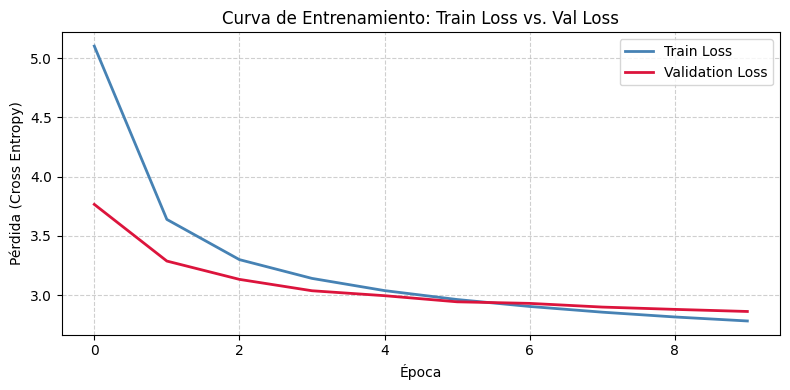


¡Entrenamiento completado!
Mejor Val Loss alcanzado: 2.8630
Pesos guardados en: /content/drive/MyDrive/Proyecto_traductor/modelos/best_model.pth


In [10]:
# ============================================
# 4. INSTANCIACIÓN, ENTRENAMIENTO Y CHECKPOINT
# ============================================

import time

# 1. Hiperparámetros actualizados
D_MODEL = 256
N_HEADS = 8
D_FF = 1024      # Mayor capacidad para memorización léxica
N_LAYERS = 3
DROPOUT = 0.15   # Regularización ajustada
MAX_POS_LEN = 100

# 2. Instanciar el modelo Transformer
model = Transformer(
    src_vocab_size=len(stoi_en),
    tgt_vocab_size=len(stoi_es),
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
    max_len=MAX_POS_LEN,
    pad_idx=PAD_IDX
).to(DEVICE)

# Guardar la configuración del modelo en JSON para el notebook de inferencia
MODEL_DIR = os.path.join(PROJ, "modelos")
os.makedirs(MODEL_DIR, exist_ok=True)

model_config = {
    "d_model": D_MODEL,
    "n_heads": N_HEADS,
    "d_ff": D_FF,
    "n_layers": N_LAYERS,
    "dropout": DROPOUT,
    "max_len": MAX_POS_LEN
}

with open(os.path.join(MODEL_DIR, "model_config.json"), "w", encoding="utf-8") as f:
    json.dump(model_config, f, indent=2)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables del Transformer: {n_params:,}")

# 3. Configurar Optimizador, Warmup Scheduler y Función de Pérdida
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.98), eps=1e-9)

WARMUP_STEPS = 2000
def lr_lambda(current_step):
    current_step = max(1, current_step)
    if current_step < WARMUP_STEPS:
        return float(current_step) / float(max(1, WARMUP_STEPS))
    return max(0.05, (WARMUP_STEPS / current_step) ** 0.5)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

# 4. Función para ejecutar una época (Train o Validation)
def run_epoch(loader, is_train=True):
    model.train() if is_train else model.eval()
    total_loss = 0.0

    with torch.set_grad_enabled(is_train):
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)

            # Desplazamiento objetivo para Teacher Forcing
            tgt_in = tgt[:, :-1]
            tgt_out = tgt[:, 1:]

            logits = model(src, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()  # <-- Calentamiento/decaimiento en cada batch

            total_loss += loss.item()

    return total_loss / len(loader)

# 5. Bucle de entrenamiento por épocas
N_EPOCHS = 10
CKPT_PATH = os.path.join(MODEL_DIR, "best_model.pth")
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}

print("\n" + "=" * 60)
print("INICIANDO ENTRENAMIENTO DEL TRANSFORMER (MEJORADO)")
print("=" * 60)

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()
    train_loss = run_epoch(train_loader, is_train=True)
    val_loss   = run_epoch(val_loader, is_train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CKPT_PATH)
        saved_mark = "   [BEST MODEL GUARDADO]"
    else:
        saved_mark = ""

    dt = time.time() - t0
    current_lr = scheduler.get_last_lr()[0]
    print(f"Época {epoch:02d}/{N_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Tiempo: {dt:.1f}s{saved_mark}")

# 6. Gráfico de curvas de entrenamiento y validación
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train Loss", color="steelblue", lw=2)
plt.plot(history["val_loss"], label="Validation Loss", color="crimson", lw=2)
plt.xlabel("Época")
plt.ylabel("Pérdida (Cross Entropy)")
plt.title("Curva de Entrenamiento: Train Loss vs. Val Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print(f"\n¡Entrenamiento completado!")
print(f"Mejor Val Loss alcanzado: {best_val_loss:.4f}")
print(f"Pesos guardados en: {CKPT_PATH}")